# See the demand. Test the decision.
## tl;dr
This fictional experiment tests whether recording unfilled customer requests improves a simple buying rule. In 20 baseline runs, full logging slightly improves fulfilment but lowers modelled contribution in every run. In the leaner-buffer scenario, it improves contribution in 13/20 runs. The answer depends on the stock policy and assumptions.

No Unified Meat Packers operational records or outcomes are used. The CV's 35% revenue achievement is separate context, not a generated target or a validated result.

## Context & Methods
Four products, 240 simulated days, first 60 excluded. Compare three capture levels and five operating scenarios over seeds 0–19. Paired policies use identical demand and supplier shocks. Today's recorded outcome informs an end-of-day order; future demand is unavailable to that decision.

### Key assumptions
Lost requests are not backlogged or substituted. Captured shortages are an exact quantity fraction, rounded to kg. Full capture is idealised. Unlimited supplier capacity; fixed prices and model shelf lives. The same order-up-to rule is used throughout, without optimality claims. Modelled contribution excludes logging labour and most operating costs.

[Methodology](docs/methodology.md) · [Research and attribution](docs/research-and-attribution.md). Censored demand is established research; this experiment does not replicate a cited paper's algorithm.

## Data
All inputs are generated by `simulate.py`. The next cell reproduces every scenario and reconciles the saved snapshot before plotting. It writes temporary outputs outside the published data directory.

In [1]:
import json, tempfile, contextlib, io
from pathlib import Path
from simulate import build
expected=json.loads(Path('data/analysis.json').read_text())
with tempfile.TemporaryDirectory() as folder:
    with contextlib.redirect_stdout(io.StringIO()):
        actual=build(folder)
assert actual==expected, 'Rerun differs from the reviewed snapshot.'
import runpy
runpy.run_path('verify.py',run_name='__main__')
print('All 300 policy runs reproduce the saved aggregates.')

PASS: 2,880 ledger rows; unique grain; daily mass balance; identical policy demand; SQL aggregate reconciliation; zero-capture equivalence; all 100 paired scenario/seed comparisons.
All 300 policy runs reproduce the saved aggregates.


## Results
### Information and policy are separate choices
Both bars in each pair use the same generated scenario. The chart reports changes from sales-only to full logging, averaged across the 20 paired runs. Positive is not universally better: it depends on the metric.

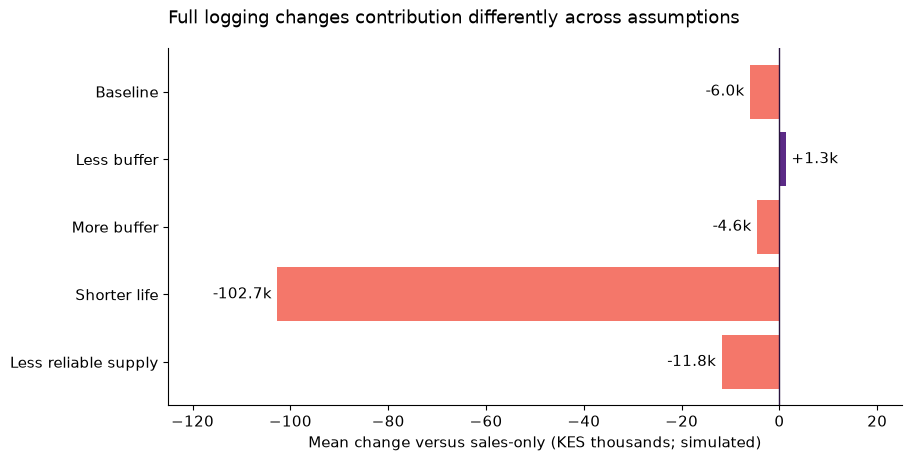

Baseline: fill 99.60% → 99.61%; contribution change KES -5,994; wins 0/20
Less buffer: fill 97.81% → 98.00%; contribution change KES +1,301; wins 13/20
More buffer: fill 99.91% → 99.91%; contribution change KES -4,551; wins 1/20
Shorter life: fill 98.79% → 98.84%; contribution change KES -102,651; wins 0/20
Less reliable supply: fill 98.40% → 98.52%; contribution change KES -11,791; wins 0/20


In [2]:
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family':'DejaVu Sans','font.size':11,'axes.spines.top':False,'axes.spines.right':False})
scenarios=list(expected['scenarios'])
names=['Baseline','Less buffer','More buffer','Shorter life','Less reliable supply']
def row(s,p):return next(r for r in expected['summary'] if r['scenario']==s and r['policy']==p)
deltas=[row(s,'all_logged')['modelled_contribution_kes']-row(s,'sales_only')['modelled_contribution_kes'] for s in scenarios]
fig,ax=plt.subplots(figsize=(9,4.5),layout='constrained')
bars=ax.barh(names,[v/1000 for v in deltas],color=['#5b2a86' if v>=0 else '#f4776a' for v in deltas])
ax.axvline(0,color='#28133e',linewidth=1);ax.invert_yaxis();ax.set_xlim(-125,25)
ax.set_title('Full logging changes contribution differently across assumptions',loc='left',pad=18)
ax.set_xlabel('Mean change versus sales-only (KES thousands; simulated)')
ax.bar_label(bars,labels=[f'{v/1000:+.1f}k' for v in deltas],padding=4)
plt.show()
for s,name in zip(scenarios,names):
    a,b=row(s,'sales_only'),row(s,'all_logged')
    print(f"{name}: fill {a['fill_rate_pct']:.2f}% → {b['fill_rate_pct']:.2f}%; contribution change KES {b['modelled_contribution_kes']-a['modelled_contribution_kes']:+,.0f}; wins {b['contribution_wins_vs_sales_only']}/20")

Full logging has a slightly positive average contribution change with less buffer, before any logging cost. That is not enough to establish a business case. The baseline already has high fulfilment; additional buying mostly adds cost. Shorter model shelf lives make this trade-off more severe.

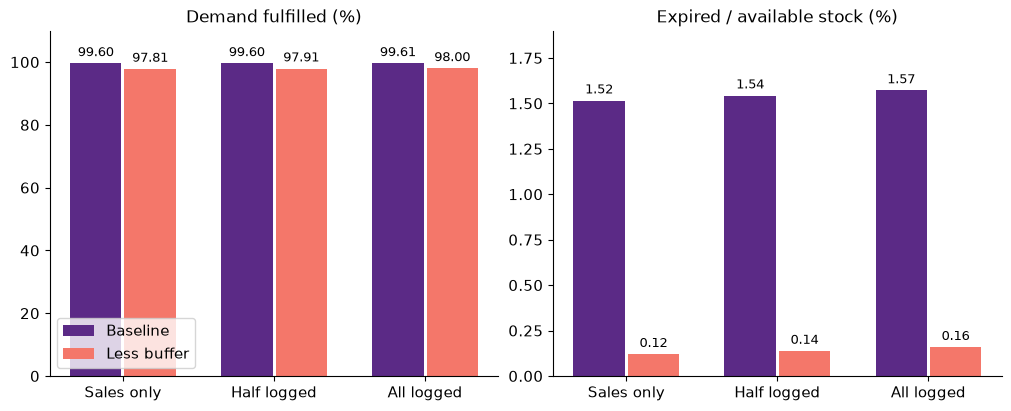

Zero-based scales. Similar fill rates require reading the labels; no exaggerated truncated axis.


In [3]:
policies=['sales_only','half_logged','all_logged'];labels=['Sales only','Half logged','All logged']
fig,axes=plt.subplots(1,2,figsize=(10,4),layout='constrained')
for ax,key,title in zip(axes,['fill_rate_pct','waste_rate_pct'],['Demand fulfilled (%)','Expired / available stock (%)']):
    for i,s in enumerate(['base','lean_buffer']):
        values=[row(s,p)[key] for p in policies]
        positions=[j+(i-.5)*.36 for j in range(3)]
        bars=ax.bar(positions,values,width=.34,color=['#5b2a86','#f4776a'][i],label=['Baseline','Less buffer'][i])
        ax.bar_label(bars,labels=[f'{v:.2f}' for v in values],padding=3,fontsize=9)
    ax.set_xticks(range(3),labels);ax.set_title(title,fontsize=12);ax.set_ylim(0,110 if key=='fill_rate_pct' else 1.9)
axes[0].legend(loc='lower left');plt.show()
print('Zero-based scales. Similar fill rates require reading the labels; no exaggerated truncated axis.')

## Takeaways
1. Propose capturing unmet requests, while measuring completion and staff effort.
2. Keep that log separate from purchase approval: more visible demand is not a command to buy more.
3. Agree service and waste constraints before a live policy trial. Include logging costs before claiming a benefit.

**Learning question:** If full logging gives a buyer more information, why can contribution still fall in this experiment? Explain the role of the unchanged replenishment rule, rather than blaming the information itself.

[Business brief and acceptance criteria](docs/business-brief.md). AI-assisted learning project; all numerical results above are synthetic.